# Mérési notebook
---
# **3. mérési fázis**. A	Modellek tesztelése teljes tanítással.

#### **Cél**: Modellek tesztelése saját adathalmazon, majd saját modell ötletek tesztelése
#### **Diplomamunka címe**: Fotográfiai témafelismerés neurális hálózatokkal nagy adathalmazon.
#### **Készítette**: Sándor Balázs - AZA6NL

## 3. modell **EfficientNet-B0** modell teljes tanítással történő tesztelése

#### A EfficientNet-B0 modell tesztelése 1k, 5k, 10k, 25k tanítás után a saját SBphotothemes180k adathalmaz Test részhalmazán. (teszt elemszám: 18k).

---

🧪 EfficientNet-B0 @ Few-shot Fine-tune – Notebook (1–5. blokk)

✅ 1. Telepítés, import, GPU ellenőrzés

In [ ]:
!pip install -q --upgrade pip
!pip install -q timm torchvision tqdm scikit-learn matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import random, os, time
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    top_k_accuracy_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("💻 Eszköz:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 172.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 140.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 130.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 152.7 MB/s eta 0:00:00
💻 Eszköz: cuda


✅ 2. Drive csatolás, adatbázis kicsomagolása

In [ ]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

diploma_path = "/content/drive/MyDrive/diplomamunka"
zip_path = os.path.join(diploma_path, "imagenet_splitted_db.zip")
extract_path = "/content/imagenet_splitted_db"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Adatok elérhetők:", extract_path)


Mounted at /content/drive
✅ Adatok elérhetők: /content/imagenet_splitted_db


Mappa pontosítás

In [ ]:
extract_path = "/content/imagenet_splitted_db/imagenet_splitted_db"

✅ 3. Adatok betöltése, stratifikált részhalmazok (1k / 5k / 10k / 25k)

In [ ]:
from collections import defaultdict

# Transzformáció
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Teljes halmazok betöltése
train_dataset_full = datasets.ImageFolder(os.path.join(extract_path, "train"), transform=transform)
val_dataset         = datasets.ImageFolder(os.path.join(extract_path, "val"), transform=transform)
test_dataset        = datasets.ImageFolder(os.path.join(extract_path, "test"), transform=transform)

# Stratifikált mintavétel
def stratified_subset(dataset, total_images):
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset.samples):
        class_indices[label].append(idx)

    per_class = total_images // len(class_indices)
    selected_indices = []

    for cls, indices in class_indices.items():
        chosen = random.sample(indices, min(per_class, len(indices)))
        selected_indices.extend(chosen)

    print(f"📦 {total_images} képes részhalmaz kész.")
    return Subset(dataset, selected_indices)

subset_sizes = [1000, 5000, 10000, 25000]
subsets = {f"{size}": stratified_subset(train_dataset_full, size) for size in subset_sizes}

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = train_dataset_full.classes
num_classes = len(class_names)


📦 1000 képes részhalmaz kész.
📦 5000 képes részhalmaz kész.
📦 10000 képes részhalmaz kész.
📦 25000 képes részhalmaz kész.


✅ 4. EfficientNet-B0 modell inicializálása új osztályszámmal

In [ ]:
import timm

def get_efficientnet_model():
    model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
    return model.to(device)


✅ 5. Általános tanítófüggvény minden részhalmazhoz

In [ ]:
def train_on_subset(train_dataset, subset_name, num_epochs=10):
    print(f"\n🚀 Tanítás: {subset_name} képes részhalmaz (EfficientNet-B0)")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    model = get_efficientnet_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    train_loss_hist, val_loss_hist = [], []
    train_acc_hist, val_acc_hist = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - train"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)

        # Validáció
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= total
        val_acc = correct / total
        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)

        print(f"📊 Epoch {epoch+1}: Train loss={train_loss:.4f}, acc={train_acc:.4f} | Val loss={val_loss:.4f}, acc={val_acc:.4f}")

    return model, train_loss_hist, val_loss_hist, train_acc_hist, val_acc_hist


🔷 BLOKK 6 – EfficientNet-B0 @ 1k részhalmaz


🚀 Tanítás: 1k képes részhalmaz (EfficientNet-B0)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/10 - train: 100%|██████████| 15/15 [00:02<00:00,  5.69it/s]


📊 Epoch 1: Train loss=4.9441, acc=0.0154 | Val loss=4.7681, acc=0.0183


...

📊 Epoch 8: Train loss=1.0787, acc=0.9627 | Val loss=3.6432, acc=0.2076


Epoch 9/10 - train: 100%|██████████| 15/15 [00:01<00:00,  9.75it/s]


📊 Epoch 9: Train loss=0.8530, acc=0.9901 | Val loss=3.5491, acc=0.2163


Epoch 10/10 - train: 100%|██████████| 15/15 [00:01<00:00,  9.62it/s]


📊 Epoch 10: Train loss=0.6692, acc=0.9901 | Val loss=3.4716, acc=0.2259


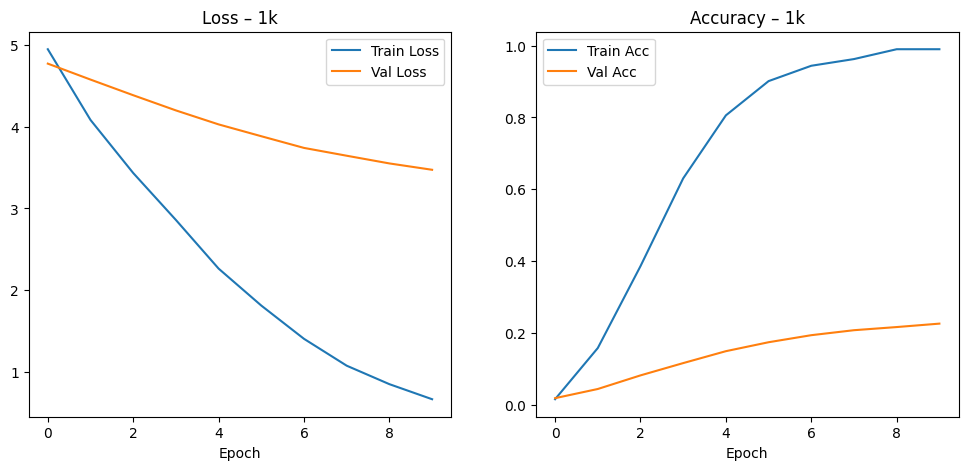


🔍 Metrikák – EfficientNet-B0 trained on 1k:
✅ Top-1 Accuracy:  0.2253
✅ Top-5 Accuracy:  0.4770
🎯 Precision:       0.2272
🎯 Recall:          0.2487
🎯 F1-score:        0.2176
⏱️ Inference time:  24.75 sec


In [ ]:
# 🔧 Tanítás 1k képen
model_1k, train_loss_1k, val_loss_1k, train_acc_1k, val_acc_1k = train_on_subset(subsets["1000"], "1k", num_epochs=10)

# 📉 Tanulási görbe – 1k
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_1k, label="Train Loss")
plt.plot(val_loss_1k, label="Val Loss")
plt.title("Loss – 1k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_1k, label="Train Acc")
plt.plot(val_acc_1k, label="Val Acc")
plt.title("Accuracy – 1k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 🧪 Tesztelés 1k modellen
model_1k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_1k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – EfficientNet-B0 trained on 1k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 7 – EfficientNet-B0 @ 5k részhalmaz


🚀 Tanítás: 5k képes részhalmaz (EfficientNet-B0)


Epoch 1/10 - train: 100%|██████████| 77/77 [00:07<00:00, 10.56it/s]


📊 Epoch 1: Train loss=4.4209, acc=0.0767 | Val loss=3.8978, acc=0.1752


Epoch 2/10 - train: 100%|██████████| 77/77 [00:07<00:00, 10.93it/s]


📊 Epoch 2: Train loss=2.9662, acc=0.3721 | Val loss=2.9698, acc=0.2947


...

📊 Epoch 8: Train loss=0.3647, acc=0.9643 | Val loss=2.2295, acc=0.4211


Epoch 9/10 - train: 100%|██████████| 77/77 [00:06<00:00, 11.05it/s]


📊 Epoch 9: Train loss=0.2604, acc=0.9812 | Val loss=2.2593, acc=0.4182


Epoch 10/10 - train: 100%|██████████| 77/77 [00:07<00:00, 10.95it/s]


📊 Epoch 10: Train loss=0.1879, acc=0.9890 | Val loss=2.2372, acc=0.4233


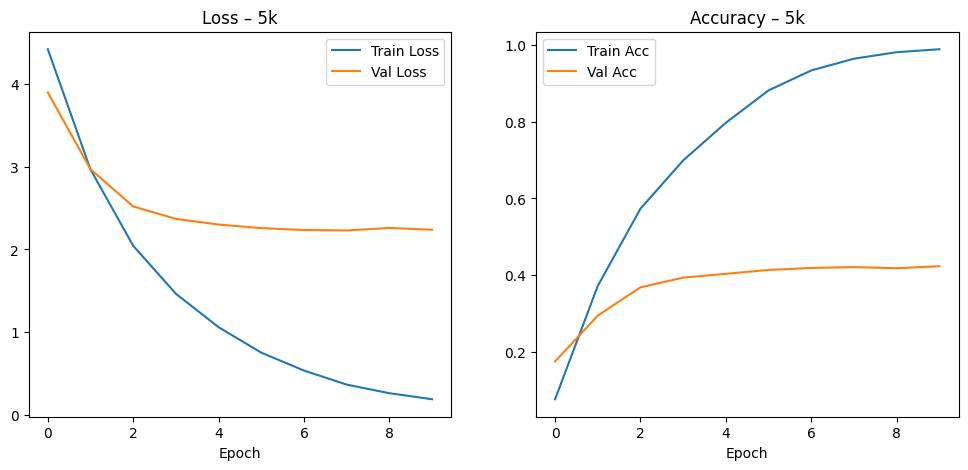


🔍 Metrikák – EfficientNet-B0 trained on 5k:
✅ Top-1 Accuracy:  0.4209
✅ Top-5 Accuracy:  0.7502
🎯 Precision:       0.4014
🎯 Recall:          0.4631
🎯 F1-score:        0.4122
⏱️ Inference time:  24.64 sec


In [ ]:
model_5k, train_loss_5k, val_loss_5k, train_acc_5k, val_acc_5k = train_on_subset(subsets["5000"], "5k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_5k, label="Train Loss")
plt.plot(val_loss_5k, label="Val Loss")
plt.title("Loss – 5k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_5k, label="Train Acc")
plt.plot(val_acc_5k, label="Val Acc")
plt.title("Accuracy – 5k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_5k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_5k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – EfficientNet-B0 trained on 5k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 8 – EfficientNet-B0 @ 10k részhalmaz


🚀 Tanítás: 10k képes részhalmaz (EfficientNet-B0)


Epoch 1/10 - train: 100%|██████████| 155/155 [00:14<00:00, 11.03it/s]


📊 Epoch 1: Train loss=3.9059, acc=0.1763 | Val loss=2.8366, acc=0.3328


Epoch 2/10 - train: 100%|██████████| 155/155 [00:14<00:00, 11.07it/s]


📊 Epoch 2: Train loss=2.2560, acc=0.4725 | Val loss=2.2879, acc=0.4172


...

📊 Epoch 8: Train loss=0.2315, acc=0.9730 | Val loss=2.0302, acc=0.4933


Epoch 9/10 - train: 100%|██████████| 155/155 [00:13<00:00, 11.12it/s]


📊 Epoch 9: Train loss=0.1615, acc=0.9839 | Val loss=2.0576, acc=0.4942


Epoch 10/10 - train: 100%|██████████| 155/155 [00:14<00:00, 10.89it/s]


📊 Epoch 10: Train loss=0.1115, acc=0.9920 | Val loss=2.0560, acc=0.5059


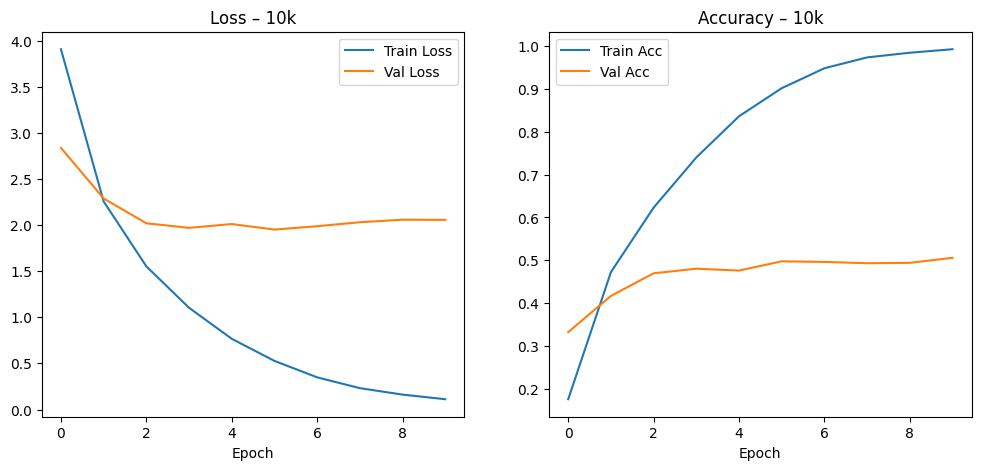


🔍 Metrikák – EfficientNet-B0 trained on 10k:
✅ Top-1 Accuracy:  0.4982
✅ Top-5 Accuracy:  0.8060
🎯 Precision:       0.4552
🎯 Recall:          0.5263
🎯 F1-score:        0.4728
⏱️ Inference time:  24.67 sec


In [ ]:
model_10k, train_loss_10k, val_loss_10k, train_acc_10k, val_acc_10k = train_on_subset(subsets["10000"], "10k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_10k, label="Train Loss")
plt.plot(val_loss_10k, label="Val Loss")
plt.title("Loss – 10k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_10k, label="Train Acc")
plt.plot(val_acc_10k, label="Val Acc")
plt.title("Accuracy – 10k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_10k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_10k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – EfficientNet-B0 trained on 10k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 9 – EfficientNet-B0 @ 25k részhalmaz


🚀 Tanítás: 25k képes részhalmaz (EfficientNet-B0)


Epoch 1/10 - train: 100%|██████████| 391/391 [00:34<00:00, 11.47it/s]


📊 Epoch 1: Train loss=2.9738, acc=0.3201 | Val loss=2.0269, acc=0.4593


Epoch 2/10 - train: 100%|██████████| 391/391 [00:34<00:00, 11.33it/s]


📊 Epoch 2: Train loss=1.6467, acc=0.5703 | Val loss=1.7581, acc=0.5119


...

📊 Epoch 8: Train loss=0.1662, acc=0.9693 | Val loss=1.9198, acc=0.5533


Epoch 9/10 - train: 100%|██████████| 391/391 [00:33<00:00, 11.52it/s]


📊 Epoch 9: Train loss=0.1234, acc=0.9787 | Val loss=2.0300, acc=0.5401


Epoch 10/10 - train: 100%|██████████| 391/391 [00:34<00:00, 11.36it/s]


📊 Epoch 10: Train loss=0.0963, acc=0.9841 | Val loss=1.9793, acc=0.5616


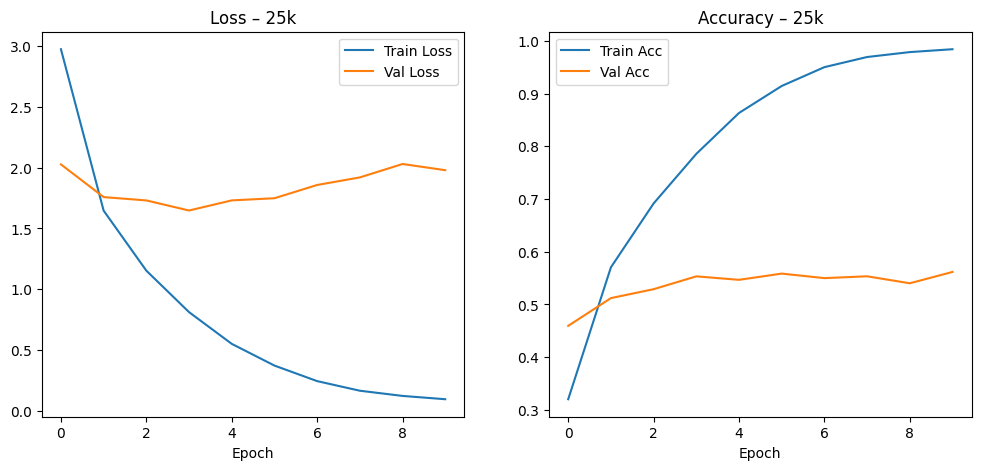


🔍 Metrikák – EfficientNet-B0 trained on 25k:
✅ Top-1 Accuracy:  0.5630
✅ Top-5 Accuracy:  0.8460
🎯 Precision:       0.5210
🎯 Recall:          0.6069
🎯 F1-score:        0.5460
⏱️ Inference time:  24.78 sec


In [ ]:
model_25k, train_loss_25k, val_loss_25k, train_acc_25k, val_acc_25k = train_on_subset(subsets["25000"], "25k", num_epochs=10)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss_25k, label="Train Loss")
plt.plot(val_loss_25k, label="Val Loss")
plt.title("Loss – 25k")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc_25k, label="Train Acc")
plt.plot(val_acc_25k, label="Val Acc")
plt.title("Accuracy – 25k")
plt.xlabel("Epoch")
plt.legend()
plt.show()

model_25k.eval()
all_preds, all_probs, all_labels = [], [], []
start = time.perf_counter()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_25k(inputs)
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

inference_time = time.perf_counter() - start
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probs = np.array(all_probs)

print("\n🔍 Metrikák – EfficientNet-B0 trained on 25k:")
print(f"✅ Top-1 Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"✅ Top-5 Accuracy:  {top_k_accuracy_score(y_true, y_probs, k=5):.4f}")
print(f"🎯 Precision:       {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 Recall:          {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"🎯 F1-score:        {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"⏱️ Inference time:  {inference_time:.2f} sec")


🔷 BLOKK 10 – 📊 Összevont tanulási görbék (Accuracy + Loss)

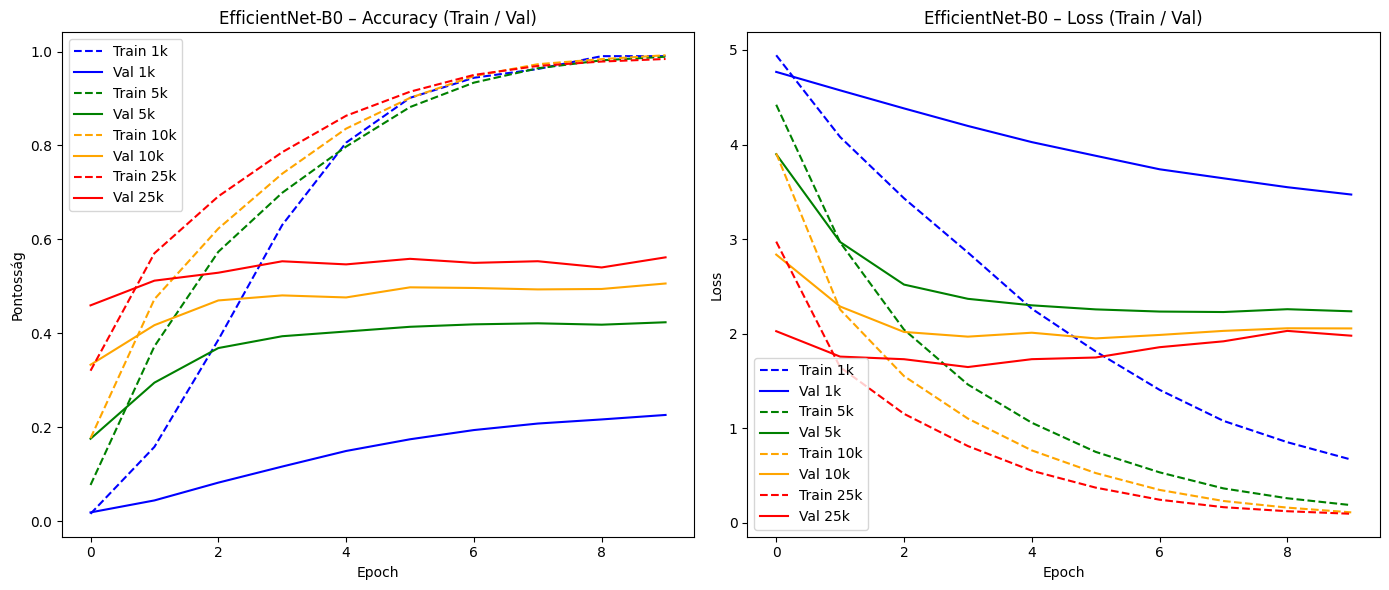

In [ ]:
plt.figure(figsize=(14, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(train_acc_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_acc_1k,   label="Val 1k",   color='blue')
plt.plot(train_acc_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_acc_5k,   label="Val 5k",   color='green')
plt.plot(train_acc_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_acc_10k,   label="Val 10k",   color='orange')
plt.plot(train_acc_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_acc_25k,   label="Val 25k",   color='red')
plt.title("EfficientNet-B0 – Accuracy (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Pontosság")
plt.legend()

# --- Loss ---
plt.subplot(1, 2, 2)
plt.plot(train_loss_1k, label="Train 1k", linestyle='--', color='blue')
plt.plot(val_loss_1k,   label="Val 1k",   color='blue')
plt.plot(train_loss_5k, label="Train 5k", linestyle='--', color='green')
plt.plot(val_loss_5k,   label="Val 5k",   color='green')
plt.plot(train_loss_10k, label="Train 10k", linestyle='--', color='orange')
plt.plot(val_loss_10k,   label="Val 10k",   color='orange')
plt.plot(train_loss_25k, label="Train 25k", linestyle='--', color='red')
plt.plot(val_loss_25k,   label="Val 25k",   color='red')
plt.title("EfficientNet-B0 – Loss (Train / Val)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


🔷 BLOKK 11 – 🟦 Confusion Matrix montázs (2×2, mini)

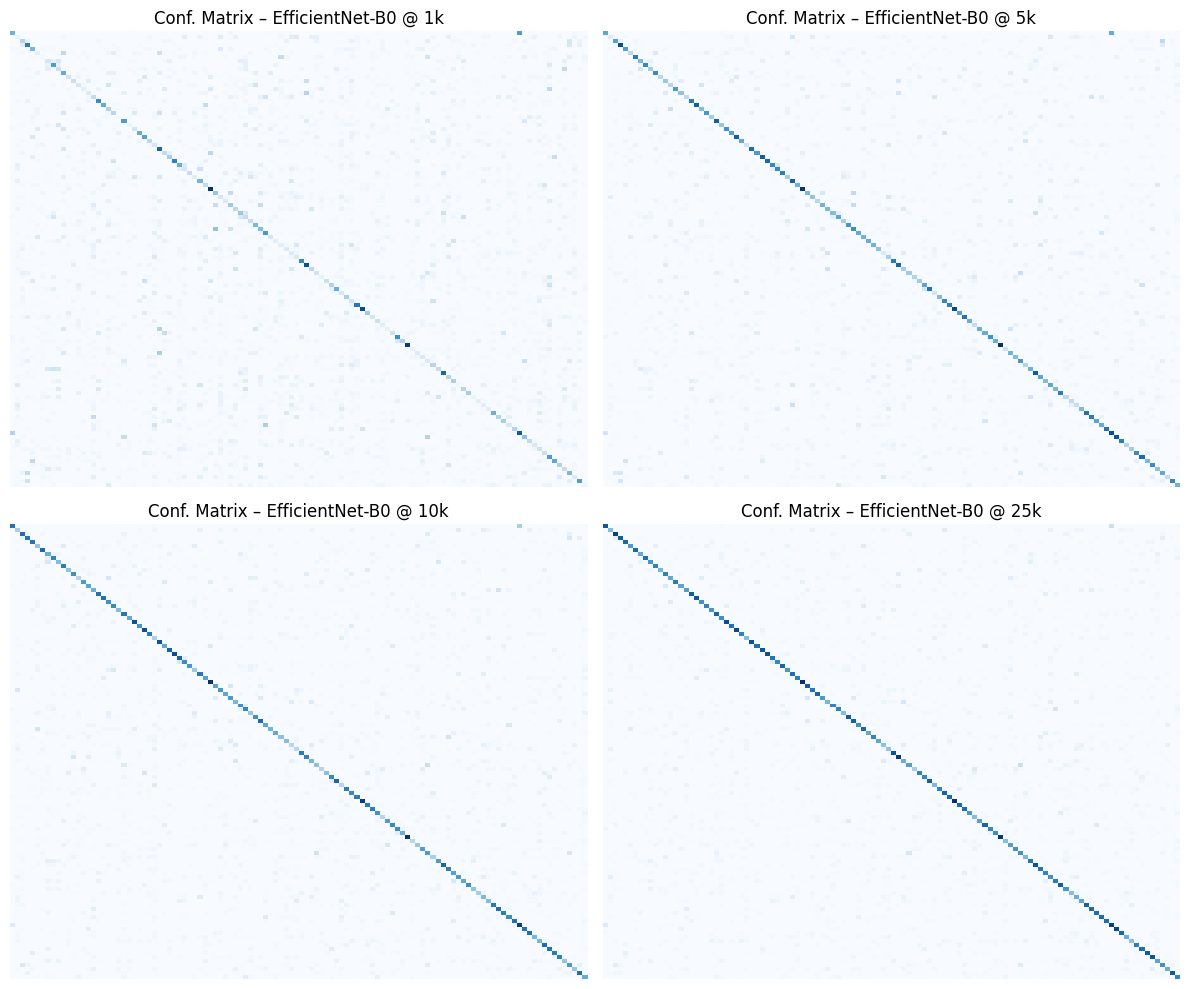

In [ ]:
import seaborn as sns

def plot_mini_confmat(model, title):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            p = torch.argmax(out, 1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.cpu().numpy())

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    sns.heatmap(cm_norm, cbar=False, xticklabels=False, yticklabels=False, cmap="Blues")

plt.figure(figsize=(12, 10))
for i, (model, title) in enumerate(zip(
    [model_1k, model_5k, model_10k, model_25k],
    ["1k", "5k", "10k", "25k"]
)):
    plt.subplot(2, 2, i+1)
    plot_mini_confmat(model, title)
    plt.title(f"Conf. Matrix – EfficientNet-B0 @ {title}")

plt.tight_layout()
plt.show()
